In [1]:
import os
import sys
import json
import time
import kaggle
from kagglehub.competition import competition_download

import numpy as np
import pandas as pd

os.environ['KAGGLE_USERNAME'] = json.load(open('/home/osman/.config/kaggle/kaggle.json'))['username']
os.environ['KAGGLE_KEY'] = json.load(open('/home/osman/.config/kaggle/kaggle.json'))['key']
path = competition_download('ing-hubs-turkiye-datathon')

/home/osman/Desktop/Projects/ING_Datathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
customer_history = pd.read_csv(f"{path}/customer_history.csv")
customers = pd.read_csv(f"{path}/customers.csv")
referance_data = pd.read_csv(f"{path}/referance_data.csv")
referance_data_test = pd.read_csv(f"{path}/referance_data_test.csv")
sample_submission = pd.read_csv(f"{path}/sample_submission.csv") 

In [3]:
referance_data_test["cust_id"].value_counts().sort_values(ascending=False)

cust_id
1         1
2         1
9         1
15        1
19        1
         ..
199951    1
199952    1
199963    1
199964    1
199979    1
Name: count, Length: 43006, dtype: int64

In [4]:
referance_data["cust_id"].value_counts().sort_values(ascending=False)

cust_id
0         1
3         1
5         1
6         1
7         1
         ..
199995    1
199996    1
199997    1
199998    1
199999    1
Name: count, Length: 133287, dtype: int64

farklı zaman damgalararında aynı müşteriye ait hiç gözlem yok hem train hem test setinde bu zaman bağımsız çalışmamızı rahatlatır

In [5]:
customers.head()

,cust_id,gender,age,province,religion,work_type,work_sector,tenure
0,0,F,64,NOH,U,Part-time,Technology,135
1,1,F,57,ZUI,O,Full-time,Finance,65
2,2,F,62,NOB,M,Self-employed,Healthcare,224
3,3,F,22,ZUI,C,Student,NaN,47
4,5,M,27,ZUI,U,Full-time,Finance,108


In [9]:
set(referance_data_test["cust_id"]) - set(customer_history["cust_id"]) 

set()

In [11]:
len(set(customer_history["cust_id"]) - set(referance_data_test["cust_id"]) )

133287

test setinde olup history de olmayan yok yani yeni müşterinin gelmediğini varsayıyoruz
history de olan ama test de olmaya 133287 gözlem var

In [17]:
train_data = customers.merge(referance_data, "right", on="cust_id")
test_data = customers.merge(referance_data_test, "right", on="cust_id")

In [20]:
train_data

,cust_id,gender,age,province,religion,work_type,work_sector,tenure,ref_date,churn
0,0,F,64,NOH,U,Part-time,Technology,135,2017-09-01,0
1,3,F,22,ZUI,C,Student,NaN,47,2018-10-01,0
2,5,M,27,ZUI,U,Full-time,Finance,108,2018-03-01,1
3,6,F,40,NOH,U,Unemployed,NaN,187,2018-04-01,1
4,7,F,64,GEL,U,Part-time,Public Sector,218,2018-05-01,0
...,...,...,...,...,...,...,...,...,...,...
133282,199995,F,54,GEL,C,Part-time,Public Sector,217,2018-09-01,0
133283,199996,M,47,GEL,C,Full-time,Public Sector,37,2018-06-01,0
133284,199997,F,66,NOB,C,Retired,NaN,227,2018-12-01,0
133285,199998,F,31,ZUI,U,Self-employed,Education,156,2018-02-01,1


In [19]:
test_data

,cust_id,gender,age,province,religion,work_type,work_sector,tenure,ref_date
0,1,F,57,ZUI,O,Full-time,Finance,65,2019-02-01
1,2,F,62,NOB,M,Self-employed,Healthcare,224,2019-01-01
2,9,M,52,GRO,C,Full-time,Healthcare,216,2019-03-01
3,15,M,63,LIM,U,Full-time,Public Sector,70,2019-06-01
4,19,M,56,NOB,C,Self-employed,Manufacturing,243,2019-01-01
...,...,...,...,...,...,...,...,...,...
43001,199951,M,27,ZUI,C,Full-time,Finance,40,2019-03-01
43002,199952,F,37,NOH,U,Self-employed,Manufacturing,228,2019-05-01
43003,199963,F,57,LIM,U,Full-time,Healthcare,228,2019-05-01
43004,199964,M,51,ZEE,U,Part-time,Healthcare,86,2019-03-01


In [29]:
train_data.isna().sum()

cust_id            0
gender             0
age                0
province           0
religion           0
work_type          0
work_sector    22767
tenure             0
ref_date           0
churn              0
dtype: int64

In [30]:
test_data.isna().sum()

cust_id           0
gender            0
age               0
province          0
religion          0
work_type         0
work_sector    7367
tenure            0
ref_date          0
dtype: int64

In [23]:
train_data["province"].value_counts()

province
ZUI    28491
NOH    22182
NOB    19767
GEL    16052
UTR    10301
OVE     8714
LIM     8416
FRI     4904
GRO     4462
DRE     3777
FLE     3275
ZEE     2946
Name: count, dtype: int64

In [25]:
train_data["religion"].value_counts()

religion
U    53283
C    39660
J    13697
M    13686
O    12961
Name: count, dtype: int64

In [27]:
train_data["work_sector"].value_counts()

work_sector
Retail           17744
Technology       17566
Healthcare       17049
Public Sector    15580
Manufacturing    15370
Education        14555
Finance          12656
Name: count, dtype: int64

In [28]:
train_data["work_type"].value_counts()

work_type
Full-time        65140
Part-time        33941
Self-employed    11439
Retired          10030
Unemployed        9313
Student           3424
Name: count, dtype: int64

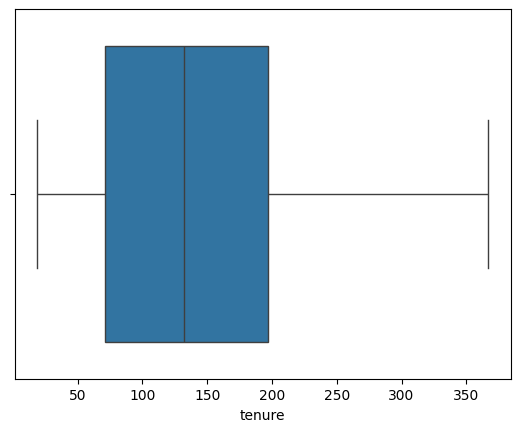

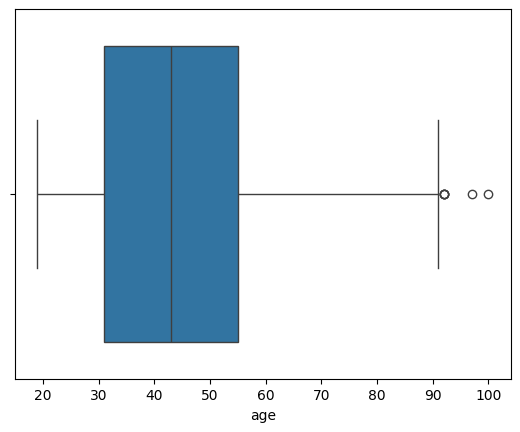

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.Figure(figsize=(5,3))
sns.boxplot(train_data["tenure"], orient="h")
plt.show()
plt.Figure(figsize=(5,15))
sns.boxplot(train_data["age"], orient="h")
plt.show()

<Axes: xlabel='age', ylabel='Count'>

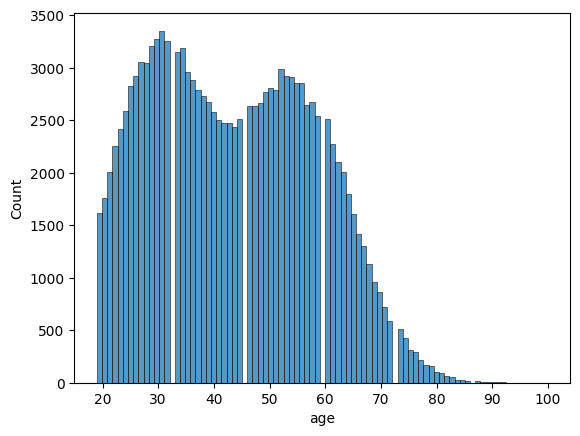

In [49]:
sns.histplot(train_data["age"])

<Axes: xlabel='tenure', ylabel='Count'>

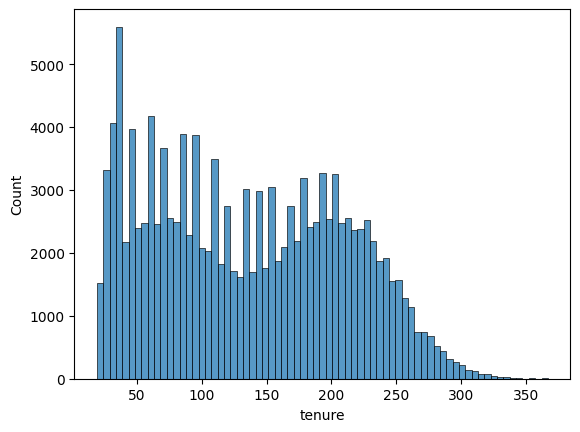

In [50]:
sns.histplot(train_data["tenure"])